In [1]:
import pandas as pd

df = pd.read_csv("data/sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
print(df.shape)
print(df.columns)
df.info()

(374, 13)
Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 

Goal of the notebook:
Sleep Quality

In [3]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [4]:
df_clean = df.drop(columns=["Blood Pressure", "Sleep Disorder"])
df_clean.describe(include="all")

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374.000000,374.000000
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,NaN,NaN
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,NaN,NaN
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,NaN,NaN
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,70.165775,6816.844920
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,4.135676,1617.915679
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,65.000000,3000.000000
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,68.000000,5600.000000
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,70.000000,7000.000000
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,72.000000,8000.000000


In [10]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=["Gender", "Occupation", "BMI Category"],
    drop_first=True
)
#df_encoded deals with making sure that the non-numeric columns are reorganized.
df_encoded.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Gender_Male,Occupation_Doctor,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,1,27,6.1,6,42,6,77,4200,True,False,...,False,False,False,False,False,True,False,False,False,True
1,2,28,6.2,6,60,8,75,10000,True,True,...,False,False,False,False,False,False,False,False,False,False
2,3,28,6.2,6,60,8,75,10000,True,True,...,False,False,False,False,False,False,False,False,False,False
3,4,28,5.9,4,30,8,85,3000,True,False,...,False,False,True,False,False,False,False,False,True,False
4,5,28,5.9,4,30,8,85,3000,True,False,...,False,False,True,False,False,False,False,False,True,False


In [13]:
X = df_encoded.drop(columns = ["Quality of Sleep"])
y = df_encoded["Quality of Sleep"]

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

model = RandomForestRegressor(random_state = 42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("RMSE: ", mean_squared_error(y_test, preds))
print("R^2: ", r2_score(y_test, preds))

RMSE:  0.028092000000000006
R^2:  0.9813790360593919


In [17]:
import pandas as pd
importance = pd.Series(model.feature_importances_, index = X.columns)
importance.sort_values(ascending = False).head(10)

Sleep Duration             0.789245
Stress Level               0.106142
Occupation_Doctor          0.036301
Heart Rate                 0.032602
Daily Steps                0.010387
Person ID                  0.009103
Age                        0.007339
BMI Category_Overweight    0.002052
Physical Activity Level    0.001719
Occupation_Engineer        0.001387
dtype: float64

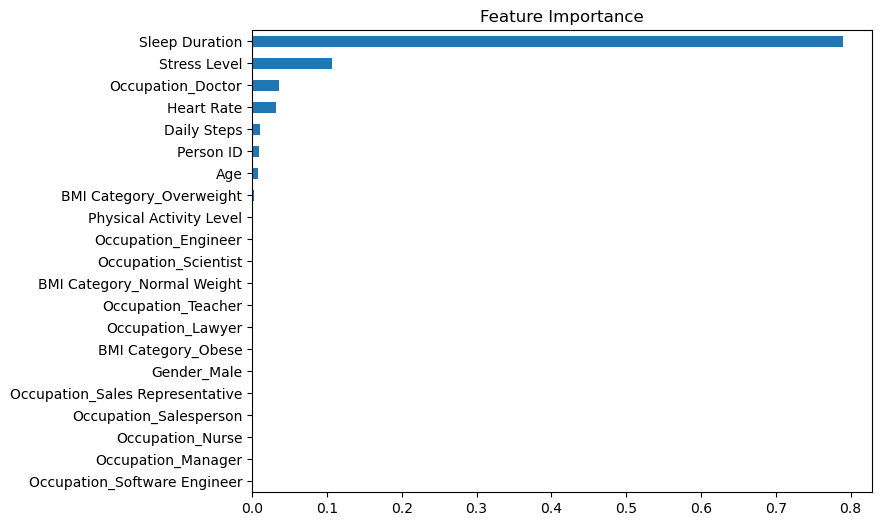

In [18]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind = 'barh', figsize = (8, 6))
plt.title("Feature Importance")
plt.show()